In [1]:
import os
from pathlib import Path
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
from rich.console import Console
from rich.table import Table

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / "tdmd").exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import jax
import jax.numpy as jnp
from pydmd import DMD

from tdmd import FFTTransform, tdmd
from examples.plasma_flow import (
    apply_tdmd_operator,
    draw_frame,
    make_plasma,
    relative_error,
    split_shifted_tensor,
)

plt.style.use("ggplot")


In [2]:
Z, t = make_plasma(nx=96, ny=96, nt=128)
train_sequence = Z[:, :, :96]
pred_idx = train_sequence.shape[2]


In [3]:
X, Y = split_shifted_tensor(train_sequence)
transform = FFTTransform()
svd_threshold = 0.0
signvals_threshold = 1.0e-8
current_window = train_sequence[:, :, 1:]

modes, schur_tensor = tdmd(
    X,
    Y,
    transform,
    svd_threshold=svd_threshold,
    signvals_threshold=signvals_threshold,
)
next_window = apply_tdmd_operator(current_window, modes, schur_tensor, transform)
snapshot_pred = next_window[:, :, -1]
snapshot_true = Z[:, :, pred_idx]
snapshot_re = relative_error(snapshot_true, snapshot_pred)

table = Table(title="Plasma TDMD")
table.add_column("Name", no_wrap=True)
table.add_column("Value")
table.add_row("sequence shape", f"{tuple(Z.shape)}")
table.add_row("modes shape", f"{tuple(modes.shape)}")
table.add_row("schur tensor shape", f"{tuple(schur_tensor.shape)}")
table.add_row("snapshot index", f"{pred_idx}")
table.add_row("snapshot RE", f"{snapshot_re:.4e}")
Console().print(table)


             Plasma TDMD              
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Name               ┃ Value         ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence shape     │ (96, 96, 128) │
│ modes shape        │ (96, 96, 95)  │
│ schur tensor shape │ (96, 96, 95)  │
│ snapshot index     │ 96            │
│ snapshot RE        │ 5.0045e-02    │
└────────────────────┴───────────────┘

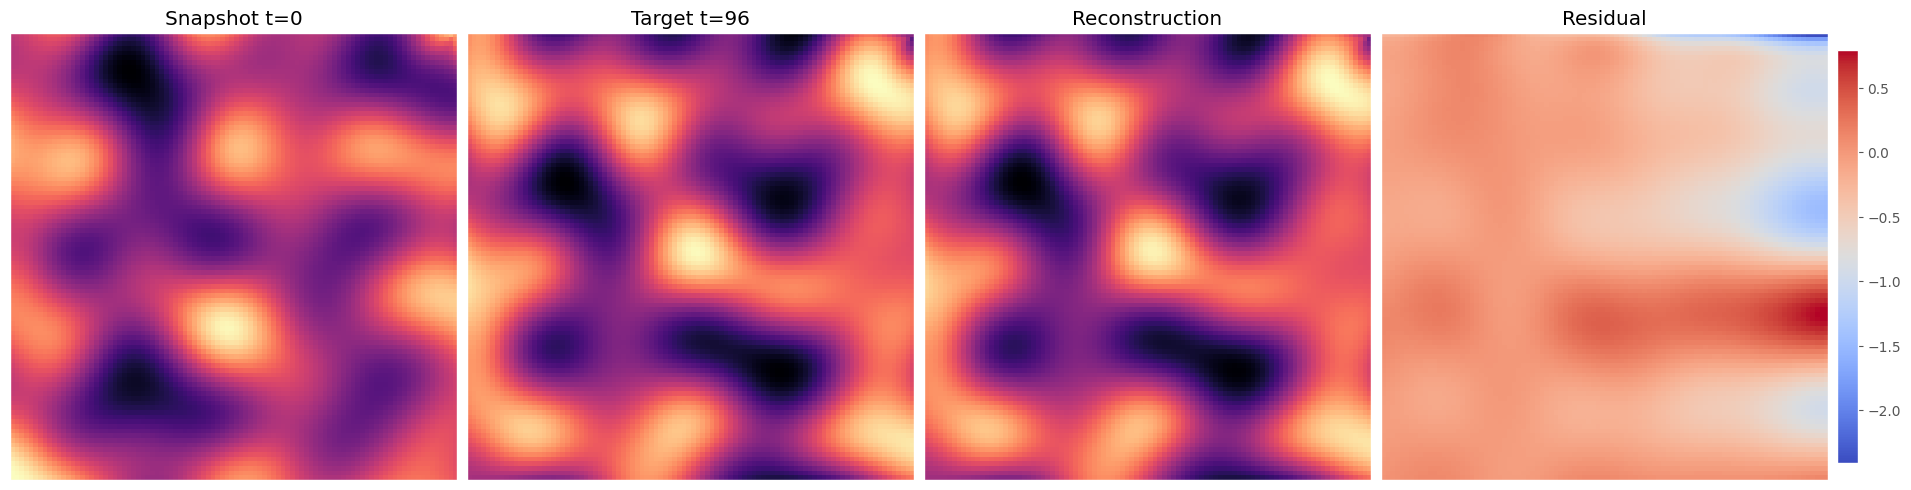

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.8), constrained_layout=True)
draw_frame(axes[0], Z[:, :, 0], "Snapshot t=0")
draw_frame(axes[1], snapshot_true, f"Target t={pred_idx}")
draw_frame(axes[2], snapshot_pred, "Reconstruction")
residual_img = draw_frame(axes[3], snapshot_true - snapshot_pred, "Residual", cmap="coolwarm")
fig.colorbar(residual_img, ax=axes[3], shrink=0.9, pad=0.02)
plt.show()
